In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy
from uncertainties import ufloat
from uncertainties.unumpy import log as ulog
import warnings
warnings.filterwarnings('ignore')

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

labelsize=12
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}


In [2]:
def frac_bin(df):
    if len(df)<15:
        return np.nan
    else:
        total_sistemas = len(df)
        
        num_binarias = len(df[df['comp_mass'] > 0])
        return num_binarias/total_sistemas
    
data = pd.read_csv('data.csv', index_col='Cluster')
data = data[data['Pmemb']>.6]
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col='Cluster')
benchmark_subsample = df[(df.dist<=1.5) & (df.Av<=0.5)]

In [8]:
df.loc['ASCC_10'].dist

0.642

In [3]:
data['mass_system'] = data.mass + data.mass*data.q
data['e_mass_system'] = unumpy.std_devs(unumpy.uarray(data.mass, data.er_mass) + unumpy.uarray(data.comp_mass, data.er_comp_mass))

In [130]:
cluster_center = []
data['r'] = np.nan
data['r/rh'] = np.nan
data['e_r'] = np.nan
data['e_r/rh'] = np.nan

df['r'] = np.nan
df['e_r'] = np.nan
df['e_r_h'] = np.nan
df['r_h'] = np.nan

r_h = []
for cluster in data.index.unique():
    coords = SkyCoord(
        ra=data['RA_ICRS'].loc[cluster].values * u.degree,
        dec=data['DE_ICRS'].loc[cluster].values * u.degree,
        distance=data['dist'].loc[cluster].values * u.pc*1000,
        frame='icrs'
    )
    
    

    cartesian = coords.cartesian
    x, y, z = cartesian.x.value, cartesian.y.value, cartesian.z.value
    
    sx = np.std(x)
    sy = np.std(x)
    sz = np.std(x)
    
    x= unumpy.uarray(x, sx)
    y= unumpy.uarray(y, sy)
    z= unumpy.uarray(z, sz)

    x_center = x.mean()
    y_center = y.mean()
    z_center = z.mean()
    
    r = unumpy.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
    
    
    massa_total = unumpy.uarray(data.loc[cluster, 'mass_system'], data.loc[cluster, 'e_mass_system']).sum()
    aux = data.loc[cluster]
    aux['r'] = r
    aux.sort_values(by='r', inplace=True)
    
    mass = 0
    for _, row in aux.iterrows():
        mass +=row['mass_system']
        if mass >= massa_total/2:
            rh = row['r']
            df.loc[cluster,'r_h'] = unumpy.nominal_values(row['r'])
            df.loc[cluster,'e_r_h'] = unumpy.std_devs(row['r'])
            break
            
    data.loc[cluster,'r'] = unumpy.nominal_values(r)
    data.loc[cluster,'e_r'] = unumpy.std_devs(r)
    
    r_rh = r/rh
    
    data.loc[cluster, 'r/rh'] = unumpy.nominal_values(r_rh)
    data.loc[cluster, 'e_r/rh'] = unumpy.std_devs(r_rh)

In [108]:
def mc_bootstrap_rh(aux, n_sim=1000):
    rh_samples = []
    for _ in range(n_sim):
        # bootstrap com reposição
        sample = aux.sample(frac=1, replace=True)

        # perturba massas via Monte Carlo
        masses = np.random.normal(sample['mass_system'], sample['e_mass_system'])
        sample = sample.copy()
        sample['mass_system'] = masses

        # ordena por raio
        sample = sample.sort_values(by='r')

        # calcula rh
        mass_total = sample['mass_system'].sum()
        mass_cum = 0
        for _, row in sample.iterrows():
            mass_cum += row['mass_system']
            if mass_cum >= mass_total/2:
                rh_samples.append(row['r'])
                break

    return np.mean(rh_samples), np.std(rh_samples)


# --- Loop principal ---
df['r_h'] = np.nan
df['e_r_h'] = np.nan

for cluster in data.index.unique():
    coords = SkyCoord(
        ra=data['RA_ICRS'].loc[cluster].values * u.degree,
        dec=data['DE_ICRS'].loc[cluster].values * u.degree,
        distance=data['dist'].loc[cluster].values * u.pc*1000,
        frame='icrs'
    )
    
    cartesian = coords.cartesian
    x, y, z = cartesian.x.value, cartesian.y.value, cartesian.z.value
    
    # incertezas aproximadas para posições
    sx, sy, sz = np.std(x), np.std(y), np.std(z)
    x = unumpy.uarray(x, sx)
    y = unumpy.uarray(y, sy)
    z = unumpy.uarray(z, sz)

    x_center = x.mean()
    y_center = y.mean()
    z_center = z.mean()

    r = unumpy.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)

    aux = data.loc[cluster].copy()
    aux['r'] = unumpy.nominal_values(r)

    # calcula rh com MC + bootstrap
    rh_mean, rh_err = mc_bootstrap_rh(aux, n_sim=1000)

    df.loc[cluster, 'r_h'] = rh_mean
    df.loc[cluster, 'e_r_h'] = rh_err

    # salva r e erros individuais
    data.loc[cluster, 'r'] = unumpy.nominal_values(r)
    data.loc[cluster, 'e_r'] = unumpy.std_devs(r)

    # normaliza r/rh
    r_rh = r / rh_mean
    data.loc[cluster, 'r/rh'] = unumpy.nominal_values(r_rh)
    data.loc[cluster, 'e_r/rh'] = unumpy.std_devs(r_rh)

KeyboardInterrupt: 

In [136]:
mass = []
e_mass =[]

r_rh = []
e_r_rh = []

q = []

bin_system_mass = []
sing_system_mass =[]

bin_system_r_rh = []
sing_system_r_rh =[]


m0 = 0
mf = 1

while m0< data.mass_system.max():
    aux = data[(data.mass_system>=m0) & (data.mass_system<mf)]
    if len(aux)>=1000:
        mass_mean = unumpy.uarray(aux.mass_system, aux.e_mass_system).mean()
        mass.append(mass_mean.nominal_value)
        e_mass.append(mass_mean.std_dev)
        
        r_rh_mean = unumpy.uarray(aux['r/rh'], aux['e_r/rh']).mean()
        r_rh.append(r_rh_mean.nominal_value)
        e_r_rh.append(r_rh_mean.std_dev)
        
        bin_system_r_rh.append(aux[aux.q>0]['r/rh'].mean())
        bin_system_mass.append(aux[aux.q>0]['mass_system'].mean())
        
        sing_system_r_rh.append(aux[aux.q==0]['r/rh'].mean())
        sing_system_mass.append(aux[aux.q==0]['mass_system'].mean())
        
        q.append(aux[aux.q>0].q.mean())
    
        m0+=1
        mf+=1
    else:
        mf+=1
    if mf>data.mass_system.max():
        break
        
mass= np.array(mass)
e_mass = np.array(e_mass)

r_rh = np.array(r_rh)
e_r_rh = np.array(e_r_rh)

bin_system_r_rh = np.array(bin_system_r_rh)
sing_system_r_rh = np.array(sing_system_r_rh)

q = np.array(q)

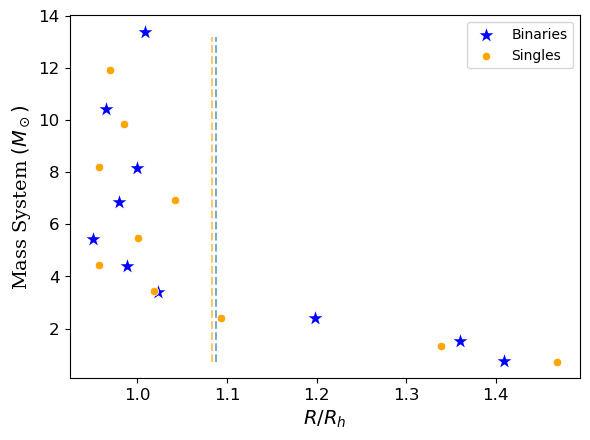

In [138]:
fig = plt.figure(figsize=(6, 5))
ax = plt.gca()

sns.scatterplot(y=bin_system_mass, x=bin_system_r_rh, label='Binaries',  color = 'b', marker='*',s=200)
sns.scatterplot(y=sing_system_mass, x=sing_system_r_rh, label='Singles', color = 'orange', marker = 'o' , )
plt.vlines(np.mean(bin_system_r_rh), min(mass), max(mass), linestyles='--', alpha=.6)
plt.vlines(np.mean(sing_system_r_rh), min(mass), max(mass), linestyles='--', alpha=.6, color='orange')


plt.ylabel(r'Mass System $(M_\odot)$', fontdict=font)
plt.xlabel(r'$R/R_h$', fontdict=font)

ax.tick_params(axis='both', labelsize=labelsize)

plt.tight_layout(rect=[0, 0, 1, 0.9])
#plt.savefig('dist_radial_massa.png',bbox_inches='tight')


plt.show()


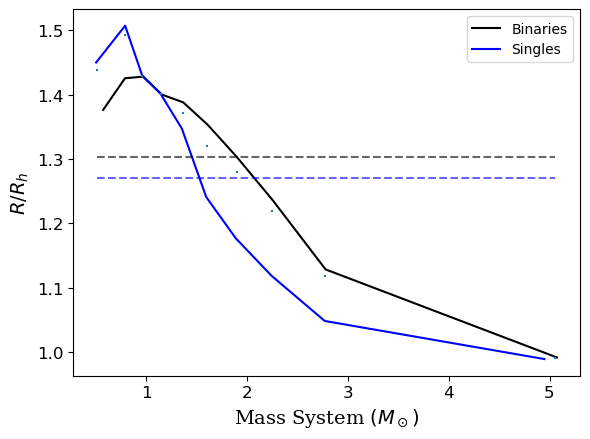

In [121]:
mass = []
e_mass =[]

r_rh = []
e_r_rh = []

q = []

bin_system_mass = []
sing_system_mass =[]

bin_system_r_rh = []
sing_system_r_rh =[]

data_benchmark = data

subgrupos = np.array_split(data_benchmark.sort_values(by='mass_system'), 10)
for aux in subgrupos:    
    mass_mean = unumpy.uarray(aux.mass_system, aux.e_mass_system).mean()
    mass.append(mass_mean.nominal_value)
    e_mass.append(mass_mean.std_dev)
        
    r_rh_mean = unumpy.uarray(aux['r/rh'], aux['e_r/rh']).mean()
    r_rh.append(r_rh_mean.nominal_value)
    e_r_rh.append(r_rh_mean.std_dev)
        
    bin_system_r_rh.append(aux[aux.q>0]['r/rh'].mean())
    bin_system_mass.append(aux[aux.q>0]['mass_system'].mean())
        
    sing_system_r_rh.append(aux[aux.q==0]['r/rh'].mean())
    sing_system_mass.append(aux[aux.q==0]['mass_system'].mean())
        
    q.append(aux[aux.q>0].q.mean())
        
mass= np.array(mass)
e_mass = np.array(e_mass)

r_rh = np.array(r_rh)
e_r_rh = np.array(e_r_rh)

bin_system_r_rh = np.array(bin_system_r_rh)
sing_system_r_rh = np.array(sing_system_r_rh)

q = np.array(q)

fig = plt.figure(figsize=(6, 5))
ax = plt.gca()

sns.lineplot(x=bin_system_mass, y=bin_system_r_rh, label='Binaries',  color = 'k',)
sns.lineplot(x=sing_system_mass, y=sing_system_r_rh, label='Singles', color = 'b',  )

plt.hlines(np.mean(bin_system_r_rh), min(mass), max(mass), linestyles='--', alpha=.6, color='k')
plt.hlines(np.mean(sing_system_r_rh), min(mass), max(mass), linestyles='--', alpha=.6, color='b')
plt.errorbar(x=mass, y=r_rh, xerr= e_mass, yerr= e_r_rh, fmt='none')


plt.xlabel(r'Mass System $(M_\odot)$', fontdict=font)
plt.ylabel(r'$R/R_h$', fontdict=font)

ax.tick_params(axis='both', labelsize=labelsize)

plt.tight_layout(rect=[0, 0, 1, 0.9])
#plt.savefig('dist_radial_massa.png',bbox_inches='tight')


plt.show()


# Tempo de relaxamento

In [6]:
df['mean_stellar_mass'] = np.nan
df['er_mean_stellar_mass'] = np.nan
df['rh'] = np.nan
df['er_rh'] = np.nan

for cluster in df.index:
    aux = data.loc[cluster]
    r = unumpy.uarray(aux.r, aux.e_r)
    r_rh = unumpy.uarray(aux['r/rh'], aux['e_r/rh'])
    rh = r/r_rh
    mass = unumpy.uarray(aux.mass_system, aux.e_mass_system).sum()
    n_members = unumpy.uarray(df.loc[cluster, 'n_members'], np.sqrt(df.loc[cluster, 'n_members']))
    mean_stellar_mass = mass/n_members
    
    df.loc[cluster, 'rh'] = unumpy.nominal_values(rh)[0]
    df.loc[cluster, 'er_rh'] = unumpy.std_devs(rh)[0]
    df.loc[cluster, 'mean_stellar_mass'] = unumpy.nominal_values(mean_stellar_mass)
    df.loc[cluster, 'er_mean_stellar_mass'] = unumpy.std_devs(mean_stellar_mass)
    df.loc[cluster, 'bin_frac'] = frac_bin(data.loc[cluster])

In [5]:
df.columns

Index(['RA_ICRS', 'DE_ICRS', 'dist', 'e_dist', 'age', 'e_age', 'FeH', 'e_FeH',
       'Av', 'e_Av', 'Nc', 'alpha_high_int', 'alpha_high_er_int',
       'alpha_low_int', 'alpha_low_er_int', 'Mc_int', 'Mc_er_int',
       'offset_int', 'offset_er_int', 'mass_total', 'e_mass_total', 'bin_frac',
       'average_ratio', 'str_average_ratio', 'segr_ratio', 'segr_ratio_std',
       'mass_seg', 'mass_seg_pval', 'n_members', 'er_bin_frac', 'Av_group',
       'dist_bin', 'dist_center', 'age_bin', 'age_center', 'FeH_bin',
       'FeH_center', 't_relax', 'er_t_relax', 'tau', 'er_tau',
       'mean_stellar_mass', 'er_mean_stellar_mass', 'rh', 'er_rh', 'q_mean',
       'er_q_mean', 'dinamical_state'],
      dtype='object')

In [100]:
# t_relax = (8.9*10**5*(N*rh**3)**0.5)/(m**0.5*log(0.4*N))

#df['t_relax'] = np.nan
#df['er_t_relax'] = np.nan

df['tau'] = np.nan
df['er_tau'] = np.nan

cte = 8.9*10**5

for cluster in df.index:
    rh = df.loc[cluster, 'rh']
    N = df.loc[cluster, 'n_members']
    m = df.loc[cluster, 'mass_total']/N
    
    
    numerador = cte*(N*rh**3)**0.5
    denominador = np.log10(0.4*N)*m**0.5
    t_relax = unumpy.uarray(numerador/denominador, df.loc[cluster, 'er_t_relax'])
    
    age = 10**unumpy.uarray(df.loc[cluster, 'age'], df.loc[cluster, 'e_age'])
    tau = age/t_relax
    
    df.loc[cluster, 't_relax'] = unumpy.nominal_values(t_relax)
    #df.loc[cluster, 'er_t_relax'] = unumpy.std_devs(t_relax)
    
    df.loc[cluster, 'tau'] = unumpy.nominal_values(tau)
    df.loc[cluster, 'er_tau'] = unumpy.std_devs(tau)

In [47]:
for cluster in df.index:
    
    M = df.loc[cluster, 'mass_total']           # Massa total (em M☉)
    dM = df.loc[cluster, 'e_mass_total']           # Erro na massa total
    r_h = df.loc[cluster, 'rh']          # Raio de meia massa (em parsecs)
    dr_h = 1e-10         # Erro no raio
    m_mean = df.loc[cluster, 'mass_total']/df.loc[cluster, 'n_members']      # Massa média estelar (em M☉)
    dm_mean = df.loc[cluster, 'e_mass_total']/(df.loc[cluster, 'n_members']  ) # Erro na massa média

    # 2. Número de simulações
    N = 100_000

    # 3. Gerar amostras aleatórias com distribuição normal
    M_samples = np.random.normal(M, dM, N)
    r_h_samples = np.random.normal(r_h, dr_h, N)
    m_mean_samples = np.random.normal(m_mean, dm_mean, N)

    # 4. Calcular t_relax para cada amostra
    # Importante: evitar log10 inválido (valores <= 0)
    valid = (M_samples > 0) & (r_h_samples > 0) & (m_mean_samples > 0) & (0.4 * M_samples / m_mean_samples > 0)
    M_samples = M_samples[valid]
    r_h_samples = r_h_samples[valid]
    m_mean_samples = m_mean_samples[valid]

    denom = m_mean_samples * np.log10(0.4 * M_samples / m_mean_samples)
    t_relax_samples = 8.9e5 * M_samples**0.5 * r_h_samples**1.5 / denom

    # 5. Estimar estatísticas
    t_relax_mean = np.mean(t_relax_samples)
    t_relax_std = np.std(t_relax_samples)
    
    
    #df.loc[cluster, 't_relax'] = t_relax_mean
    df.loc[cluster, 'er_t_relax'] = t_relax_std


In [54]:
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col='Cluster')
for cluster in df.index:
    df.loc[cluster, 'bin_systems'] = len(data[data.q>0].loc[cluster])


In [55]:
df.tau

Cluster
ASCC_10         3.803257
ASCC_105        1.776120
ASCC_107        3.008105
ASCC_108        0.275681
ASCC_11         4.133122
                 ...    
UPK_93         10.911555
UPK_94         10.184202
vdBergh_130     1.147533
vdBergh_80      0.437310
vdBergh_92      0.188676
Name: tau, Length: 771, dtype: float64

In [6]:
# Ordenar o DataFrame por tau
df_sorted = df.sort_values(by='tau').reset_index(drop=True)

# Tamanho mínimo por grupo
tamanho_grupo = 70

# Dividir em grupos de ~100
n_total = len(df_sorted)
grupos = [df_sorted.iloc[i:i + tamanho_grupo] for i in range(0, n_total, tamanho_grupo)]



# Inicializar listas
medias_tau = []
medias_bin_frac = []
erros_tau = []
erros_bin_frac = []
rh =[]
medias_rh =[]
erros_rh = []
medias_bin_systems = []
erros_bin_systems = []
for g in grupos:
    if len(g) >= tamanho_grupo:
        
        
        tau = unumpy.uarray(g['tau'], g['er_tau']).mean()
        medias_tau.append(unumpy.nominal_values(tau))
        erros_tau.append(unumpy.std_devs(tau))
        
        mean_fb = unumpy.uarray(g.bin_frac, g.er_bin_frac).mean()
        medias_bin_frac.append(unumpy.nominal_values(mean_fb))
        erros_bin_frac.append(unumpy.std_devs(mean_fb))
        
        mean_rh = unumpy.uarray(g.r_h, g.e_r_h).mean()
        medias_rh.append(unumpy.nominal_values(mean_rh))
        erros_rh.append(unumpy.std_devs(mean_rh))
        
        mean_bs= unumpy.uarray(g.bin_systems, np.std(g.bin_systems)).mean()
        medias_bin_systems.append(unumpy.nominal_values(mean_bs))
        erros_bin_systems.append(unumpy.std_devs(mean_bs))
        

medias_tau = np.array(medias_tau)  
erros_tau = np.array(erros_tau)
medias_bin_frac= np.array(medias_bin_frac)
# Plotar com barras de erro
fig, axs = plt.subplots(2,1, figsize=(6, 8))


sns.regplot(x=medias_tau, y=medias_bin_frac, ax=axs[0])
axs[0].errorbar(
    medias_tau, medias_bin_frac,
    yerr=erros_bin_frac, xerr = erros_tau,
    fmt='none', elinewidth=1, capsize=2,)

axs[0].set_xlabel(r'$\tau$', fontdict=font)
axs[0].set_ylabel('Binary fraction', fontdict=font)


sns.regplot(x=medias_tau, y=np.array(medias_bin_systems), ax=axs[1], ci=80)
axs[1].errorbar(
    medias_tau, medias_bin_systems,
    xerr = erros_tau,
    fmt='none', elinewidth=1, capsize=2,)

axs[1].set_xlabel(r'$\tau$', fontdict=font)
axs[1].set_ylabel('Average of binary systems', fontdict=font)

axs[0].tick_params(labelsize=labelsize)
axs[1].tick_params(labelsize=labelsize)
axs[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('fb_tau.png', bbox_inches='tight')
plt.show()


AttributeError: 'DataFrame' object has no attribute 'bin_systems'

<Axes: xlabel='q', ylabel='Percent'>

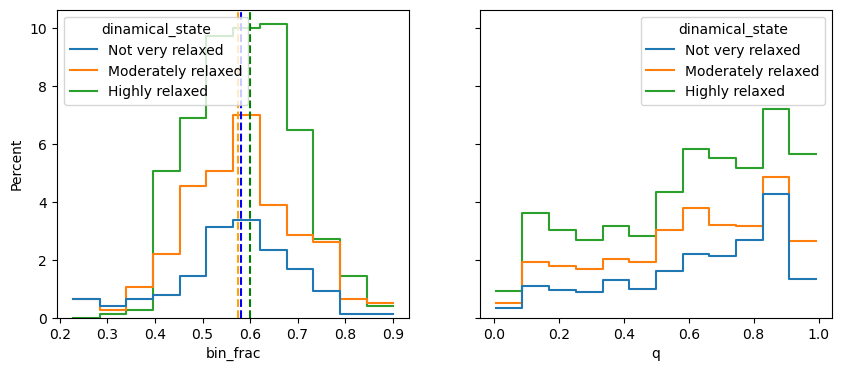

In [146]:
aux = data[data.q>0]
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)

sns.histplot(data=df, x='bin_frac', hue = 'dinamical_state', bins=12, stat='percent', fill=False, element='step', ax=axs[0],
            hue_order=['Not very relaxed', 'Moderately relaxed', 'Highly relaxed'])
axs[0].axvline(df[df.tau<1].bin_frac.median(),  linestyle='--', c='b')
axs[0].axvline(df[(df.tau>=1) & (df.tau<10)].bin_frac.median(),  linestyle='--', c = 'orange')
axs[0].axvline(df[df.tau>=10].bin_frac.median(),  linestyle='--', c = 'g')

sns.histplot(data=aux, x='q', hue = 'dinamical_state', bins=12, stat='percent', fill=False, element='step', ax=axs[1],
            hue_order=['Not very relaxed', 'Moderately relaxed', 'Highly relaxed'])

#sns.histplot(data=data[data.q>0], x='q', hue =  'dinamical_state', bins=12, stat='percent')

In [6]:
data[data.dinamical_state == 'Not very relaxed']

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Plx,e_Plx,pmRA,...,er_q,mass_system,e_mass_system,r,r/rh,e_r,e_r/rh,t_seg,tau,dinamical_state
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_108,-0.1282,-0.0418,-0.1342,297.827729,0.0399,39.012330,0.0481,0.8119,0.0512,-0.568,...,0.239536,1.104194,0.188388,10.855599,0.692991,11.438250,0.889097,7.345372,0.258375,Not very relaxed
ASCC_108,-0.2142,0.1755,-0.1642,298.726470,0.0784,39.649411,0.0923,0.8776,0.0991,-0.214,...,0.105287,1.067249,0.069116,8.298613,0.529760,11.438250,0.825724,7.599643,0.258375,Not very relaxed
ASCC_108,-0.1060,0.0091,-0.0856,297.907254,0.0758,38.952999,0.0829,0.9429,0.0925,-0.401,...,0.121141,0.665367,0.080630,10.727617,0.684821,11.438250,0.885716,12.189827,0.258375,Not very relaxed
ASCC_108,-0.0677,0.0348,-0.0362,297.988496,0.0653,38.900279,0.0735,0.7040,0.0803,-0.524,...,0.043403,0.703109,0.030548,10.749491,0.686218,11.438250,0.886285,11.535503,0.258375,Not very relaxed
ASCC_108,-0.1242,-0.0551,-0.1977,298.625204,0.0964,39.734614,0.1230,0.8015,0.1295,-0.446,...,0.286433,0.861062,0.180061,8.884590,0.567168,11.438250,0.838856,9.419429,0.258375,Not very relaxed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vdBergh_92,-0.0501,0.1582,0.0278,106.005495,0.0761,-11.604856,0.0820,0.9346,0.0905,-4.379,...,0.000000,0.751410,0.004198,2.514689,1.017729,2.365196,1.367089,10.482411,0.181549,Not very relaxed
vdBergh_92,-0.1744,-0.0782,0.0656,106.083301,0.0667,-11.372899,0.0733,0.9971,0.0824,-4.507,...,0.124435,0.742573,0.092548,2.184711,0.884182,2.365196,1.276774,10.607156,0.181549,Not very relaxed
vdBergh_92,-0.2079,0.1070,0.2052,106.166213,0.2012,-11.472170,0.2035,0.8268,0.2374,-4.409,...,0.155791,0.444121,0.072986,1.820391,0.736737,2.365196,1.187953,17.735239,0.181549,Not very relaxed


In [ ]:
# Listas de saída
mass = []
e_mass = []

r_rh = []
e_r_rh = []

q = []

bin_system_mass = []
bin_system_r_rh = []

sing_system_mass = []
sing_system_r_rh = []

# Bins móveis de mass_system
m0 = 0
mf = 0.5

while m0 < data.mass_system.max():
    # Seleciona o bin de mass_system atual
    aux = data[(data.mass_system >= m0) & (data.mass_system < mf)]

    # Garante no mínimo 10.000 sistemas
    if len(aux) >= 10000:
        # Média com erro usando uncertainties
        mass_mean = unumpy.uarray(aux.mass_system, aux.e_mass_system).mean()
        r_rh_mean = unumpy.uarray(aux['r/rh'], aux['e_r/rh']).mean()

        mass.append(mass_mean.nominal_value)
        e_mass.append(mass_mean.std_dev)

        r_rh.append(r_rh_mean.nominal_value)
        e_r_rh.append(r_rh_mean.std_dev)

        # Sistemas binários (q > 0)
        bin_aux = aux[aux.q > 0]
        bin_system_mass.append(bin_aux.mass_system.mean())
        bin_system_r_rh.append(bin_aux['r/rh'].mean())
        q.append(bin_aux.q.mean())

        # Sistemas singulares (q == 0)
        sing_aux = aux[aux.q == 0]
        sing_system_mass.append(sing_aux.mass_system.mean())
        sing_system_r_rh.append(sing_aux['r/rh'].mean())

        # Avança bin de forma fixa
        m0 += 0.5
        mf += 0.5
    else:
        # Aumenta o intervalo até encontrar bin com >=10000
        mf += 0.5

    # Segurança para não extrapolar
    if mf > data.mass_system.max():
        break

# Convertendo listas para arrays numpy
mass = np.array(mass)
e_mass = np.array(e_mass)

r_rh = np.array(r_rh)
e_r_rh = np.array(e_r_rh)

bin_system_mass = np.array(bin_system_mass)
bin_system_r_rh = np.array(bin_system_r_rh)

sing_system_mass = np.array(sing_system_mass)
sing_system_r_rh = np.array(sing_system_r_rh)

q = np.array(q)




<Axes: >

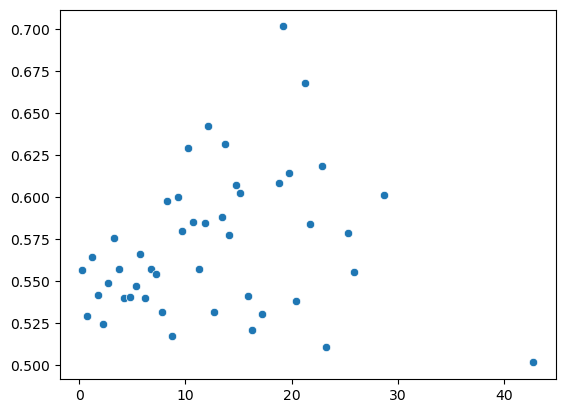

In [58]:
sns.scatterplot(x=tau_values, y=fb)

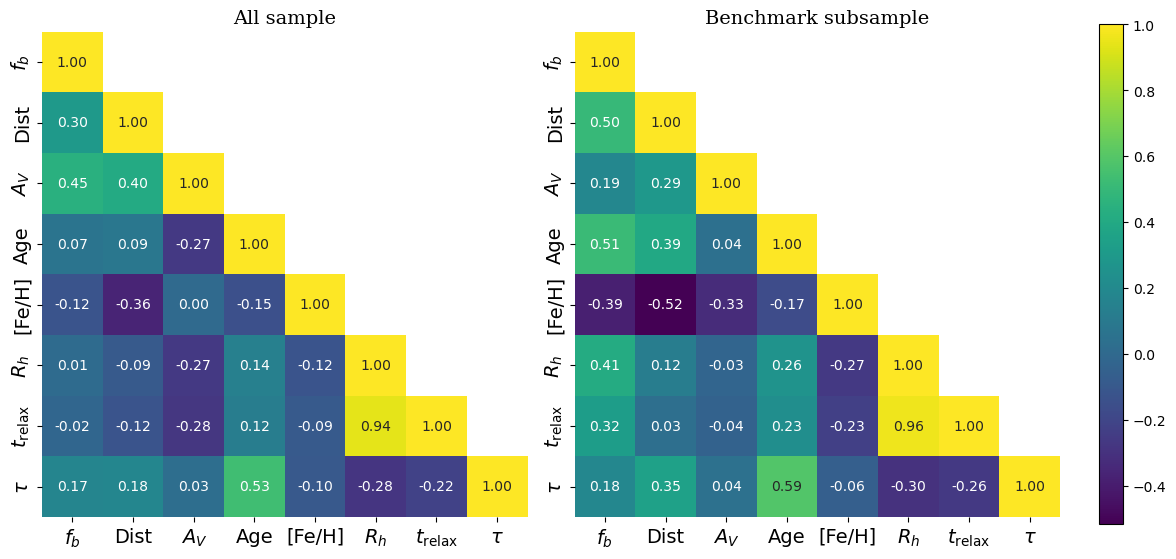

In [91]:
# Dicionário com nomes mais apresentáveis
nome_vars = {
    'bin_frac': r'$f_b$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[Fe/H]',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$'
}


cols = list(nome_vars.keys())

corr1 = df[cols].corr()

gold = df[(df.dist<=1) & (df.Av<=0.5) ]
corr2 = gold[cols].corr()


corr1.rename(index=nome_vars, columns=nome_vars, inplace=True)
corr2.rename(index=nome_vars, columns=nome_vars, inplace=True)


mask1 = np.triu(np.ones_like(corr1, dtype=bool), k=1)
mask2 = np.triu(np.ones_like(corr2, dtype=bool), k=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 10))
vmin, vmax = min(min(corr1.min()),min(corr2.min())), 1
cmap = palette

sns.heatmap(
    corr1,
    mask=mask1,
    annot=True,
    cmap=cmap,
    fmt=".2f",
    square=True,
    ax=axs[0],
    cbar=False,
    vmin=vmin, vmax=vmax
)

sns.heatmap(
    corr2,
    mask=mask2,
    annot=True,
    cmap=cmap,
    fmt=".2f",
    square=True,
    ax=axs[1],
    cbar=False,
    vmin=vmin, vmax=vmax
)

for ax in axs:
    for label in ax.get_xticklabels():
      
        label.set_fontsize(14)

    for label in ax.get_yticklabels():
        label.set_fontsize(14)

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, .5])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)


axs[0].set_title('All sample', fontdict=font)
axs[1].set_title('Benchmark subsample', fontdict=font)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('corr.png',bbox_inches='tight')
plt.show()


In [56]:
resultados =pd.DataFrame(index=df.index)

resultados[r'$f_b$'] = unumpy.uarray(df['bin_frac'], df['er_bin_frac'])
resultados[r'$t_{relax}$ [Myr]'] = unumpy.uarray(df['t_relax']/1e6, df['er_t_relax']/1e6)
resultados[r'$\tau$'] = unumpy.uarray(df['tau'], df['er_tau'])
resultados[r'$R_h$'] = df['rh']
def format_ufloat(x):
    return f"{x.nominal_value:.2f} ± {x.std_dev:.2f}"
tabela_formatada = resultados.copy()

for col in resultados.columns:
    if resultados[col].dtype == 'O':  # coluna com ufloat
        tabela_formatada[col] = resultados[col].apply(format_ufloat)
    else:
        tabela_formatada[col] = resultados[col].map("{:.2f}".format)
        
latex = tabela_formatada.to_latex(index=True, escape=False)


In [66]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(df.t_relax, gold.t_relax)

print(f'Estatística KS: {stat}')
print(f'Valor-p: {p_value}')

Estatística KS: 0.36916942883220444
Valor-p: 1.8854071446892733e-09


In [89]:
p_values = {}

for col in cols:
    stat, p_value = ks_2samp(df[col], gold[col])
    p_values[col] = p_value

# Converter para DataFrame
comparacao = pd.DataFrame.from_dict(p_values, orient='index', columns=['p_value'])
comparacao.index.name = 'Parâmetro'

In [92]:
from scipy.stats import norm
import numpy as np

def fisher_z_test(r1, n1, r2, n2):
    # Fisher z-transform
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Erro padrão
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    
    # Estatística z
    z = (z1 - z2) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))  # teste bicaudal
    return z, p_value

results = []

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        var1, var2 = cols[i], cols[j]

        # Correlações
        r1 = df[[var1, var2]].corr().iloc[0, 1]
        r2 = gold[[var1, var2]].corr().iloc[0, 1]

        # Tamanhos das amostras
        n1 = df[[var1, var2]].dropna().shape[0]
        n2 = gold[[var1, var2]].dropna().shape[0]

        # Teste de Fisher-Z
        z, p = fisher_z_test(r1, n1, r2, n2)

        results.append({
            'Var1': var1,
            'Var2': var2,
            'Corr_All': r1,
            'Corr_Sub': r2,
            'Z': z,
            'p_value': p
        })

# Converter para DataFrame
comparacao_correlacoes = pd.DataFrame(results)

In [102]:
df['X'] = df['dist']*np.cos(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Y'] = df['dist']*np.sin(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Z'] = df['dist']*np.sin(df['DE_ICRS'])

<Axes: xlabel='X', ylabel='Z'>

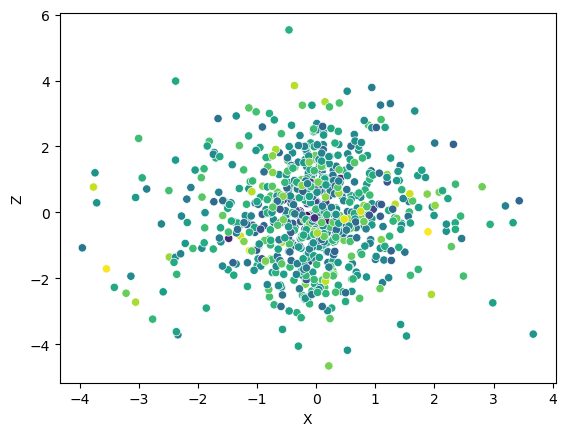

In [107]:
sns.scatterplot(data=df, x='X',y='Z', hue='bin_frac', palette=palette, legend=None)

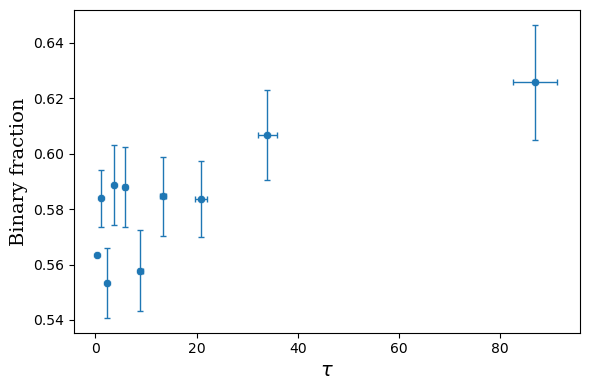

In [34]:
# Ordenar o DataFrame por tau
df_sorted = df.sort_values(by='tau').reset_index(drop=True)

# Tamanho mínimo por grupo
tamanho_grupo = 77

# Dividir em grupos de ~100
n_total = len(df_sorted)
grupos = [df_sorted.iloc[i:i + tamanho_grupo] for i in range(0, n_total, tamanho_grupo)]



# Inicializar listas
medias_tau = []
medias_bin_frac = []
erros_tau = []
erros_bin_frac = []
rh =[]
medias_rh =[]
erros_rh = []
medias_bin_systems = []
erros_bin_systems = []
for g in grupos:
    if len(g) >= tamanho_grupo:
        
        
        tau = unumpy.uarray(g['tau'], g['er_tau']).mean()
        medias_tau.append(unumpy.nominal_values(tau))
        erros_tau.append(unumpy.std_devs(tau))
        
        mean_fb = unumpy.uarray(g.bin_frac, g.er_bin_frac).mean()
        medias_bin_frac.append(unumpy.nominal_values(mean_fb))
        erros_bin_frac.append(np.std(medias_bin_frac))
        
        mean_rh = unumpy.uarray(g.r_h, g.e_r_h).mean()
        medias_rh.append(unumpy.nominal_values(mean_rh))
        erros_rh.append(unumpy.std_devs(mean_rh))
        
        mean_bs= unumpy.uarray(g.bin_systems, np.std(g.bin_systems)).mean()
        medias_bin_systems.append(unumpy.nominal_values(mean_bs))
        erros_bin_systems.append(unumpy.std_devs(mean_bs))
        
        

        

medias_tau = np.array(medias_tau)  
erros_tau = np.array(erros_tau)
medias_bin_frac= np.array(medias_bin_frac)
# Plotar com barras de erro
fig= plt.figure(figsize=(6, 4))


sns.scatterplot(x=medias_tau, y=medias_bin_frac)
plt.errorbar(
    medias_tau, medias_bin_frac,
    yerr=erros_bin_frac, xerr = erros_tau,
    fmt='none', elinewidth=1, capsize=2,)

plt.xlabel(r'$\tau$', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.tight_layout()

#plt.savefig('fb_tau.png', dpi=300)
plt.show()


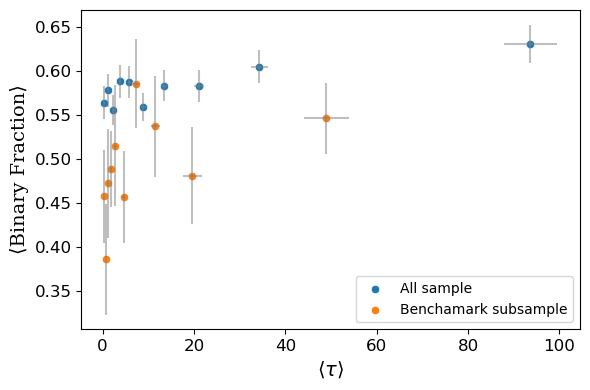

In [72]:
subconjuntos = np.array_split(df.sort_values(by='tau'), 10)
subconjuntos_benchmark = np.array_split(benchmark_subsample.sort_values(by='tau'), 10)

tau_mean = []
tau_benchmark_mean = []
bin_frac_mean = []
bin_frac_benchmark_mean = []

for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["er_tau"].values
    tau_ufloats = unumpy.uarray(tau_vals, tau_errs)
    tau_mean.append((tau_ufloats).mean())

    tau_b_vals = subconjuntos_benchmark[i]["tau"].values
    tau_b_errs = subconjuntos_benchmark[i]["er_tau"].values
    tau_b_ufloats = unumpy.uarray(tau_b_vals, tau_b_errs)
    tau_benchmark_mean.append((tau_b_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac"].values
    bf_errs = subconjuntos[i]["er_bin_frac"].values
    bf_ufloats = unumpy.uarray(bf_vals, bf_errs)
    bin_frac_mean.append((bf_ufloats).mean())

    bf_b_vals = subconjuntos_benchmark[i]["bin_frac"].values
    bf_b_errs = subconjuntos_benchmark[i]["er_bin_frac"].values
    bf_b_ufloats = unumpy.uarray(bf_b_vals, bf_b_errs)
    bin_frac_benchmark_mean.append((bf_b_ufloats).mean())

tau_mean = np.array(tau_mean)
tau_benchmark_mean = np.array(tau_benchmark_mean)
bin_frac_mean = np.array(bin_frac_mean)
bin_frac_benchmark_mean = np.array(bin_frac_benchmark_mean)

x = unumpy.nominal_values(tau_mean)
y = unumpy.nominal_values(bin_frac_mean)
xerr = unumpy.std_devs(tau_mean)
yerr = unumpy.std_devs(bin_frac_mean)

x_bench = unumpy.nominal_values(tau_benchmark_mean)
y_bench = unumpy.nominal_values(bin_frac_benchmark_mean)
xerr_bench = unumpy.std_devs(tau_benchmark_mean)
yerr_bench = unumpy.std_devs(bin_frac_benchmark_mean)

fig = plt.figure(figsize=(6, 4))
sns.scatterplot(x=x, y=y, label = 'All sample')
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', ecolor='gray', alpha=0.5)

sns.scatterplot(x=x_bench, y=y_bench, label='Benchamark subsample')
plt.errorbar(x_bench, y_bench, xerr=xerr_bench, yerr=yerr_bench, fmt='none', ecolor='gray', alpha=0.5)

plt.xlabel(r"⟨$\tau$⟩", fontdict=font)
plt.ylabel("⟨Binary Fraction⟩", fontdict=font)

plt.tick_params(axis='both', labelsize=labelsize)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fb_tau.png', dpi=300)
plt.show()


In [57]:
unumpy.uarray(subconjuntos[i].tau,subconjuntos[i].er_tau).mean()

0.3966330755300981+/-0.020402928588075225

Cluster
ASCC_9          0.014693
UBC_31          0.027487
BH_205          0.027027
Pozzo_1         0.037368
UBC_292         0.024519
                  ...   
UPK_640         0.132363
NGC_7039        0.212193
COIN-Gaia_13    0.233002
UBC_479         0.171234
Pismis_5        0.291883
Name: er_tau, Length: 78, dtype: float64